# **Decomposição multiplicativa**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
rcParams['figure.figsize'] =15,7
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
# 1. Carregar a série temporal AirPassengers
dataset = sm.datasets.get_rdataset("AirPassengers").data
datas = pd.date_range(start='1949-01-01', periods=len(dataset), freq='MS')
air_passengers = pd.Series(dataset['value'].values, index=datas, name='Passengers')

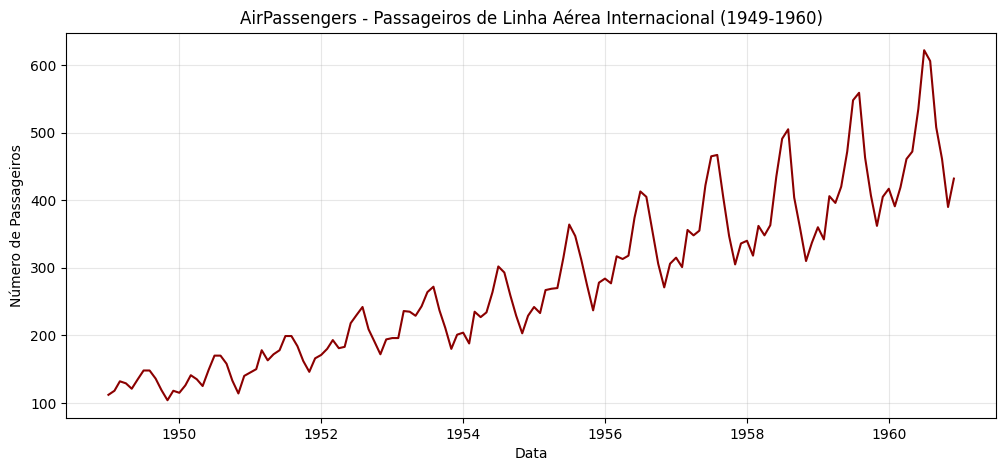

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(air_passengers.index, air_passengers, linewidth=1.5, color='darkred')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.title('AirPassengers - Passageiros de Linha Aérea Internacional (1949-1960)')
plt.grid(alpha=0.3)
plt.show()

In [8]:
# 2. Decomposição da Série Temporal (Modelo Multiplicativo)
decomposicao = seasonal_decompose(air_passengers, model='multiplicative', period=12)

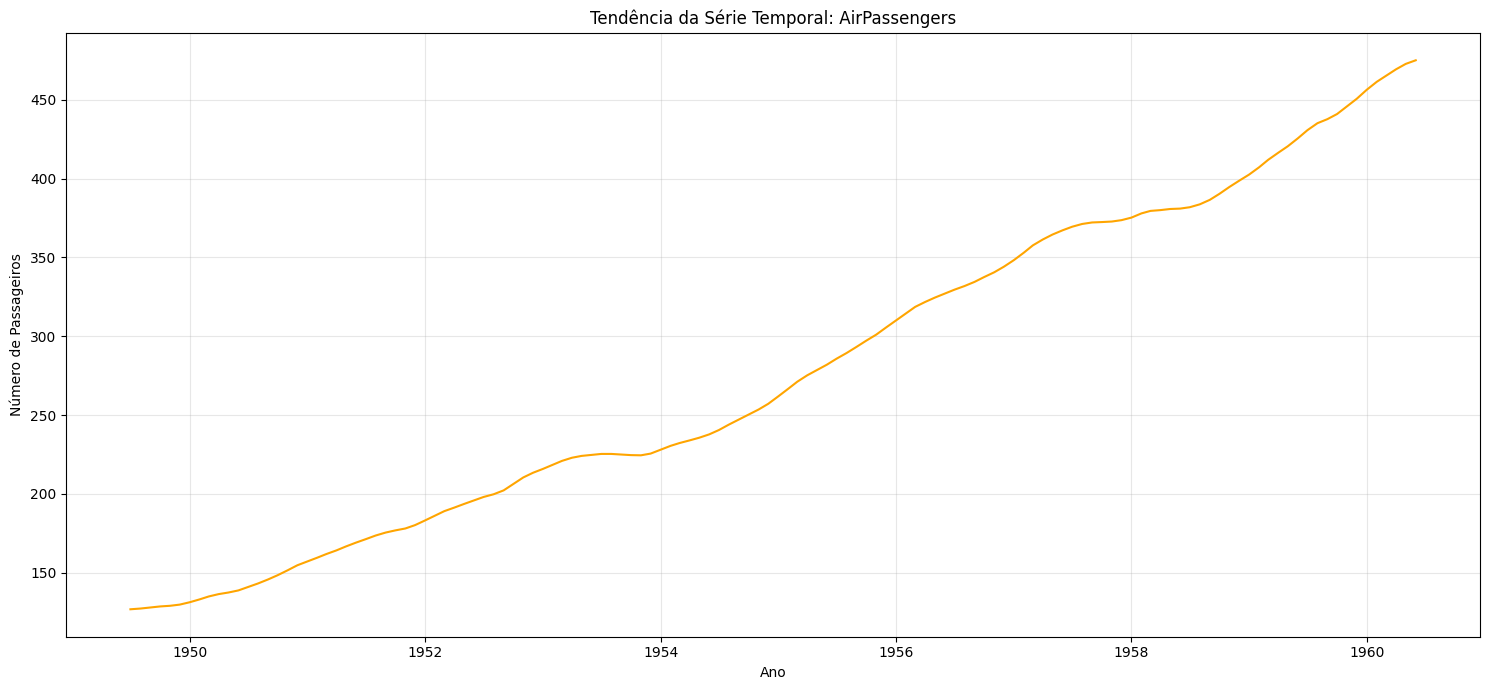

In [9]:
# Gráfico da Tendência
plt.plot(air_passengers.index, decomposicao.trend, color='Orange', label='Tendência (T)')
plt.xlabel("Ano")
plt.ylabel("Número de Passageiros")
plt.title("Tendência da Série Temporal: AirPassengers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

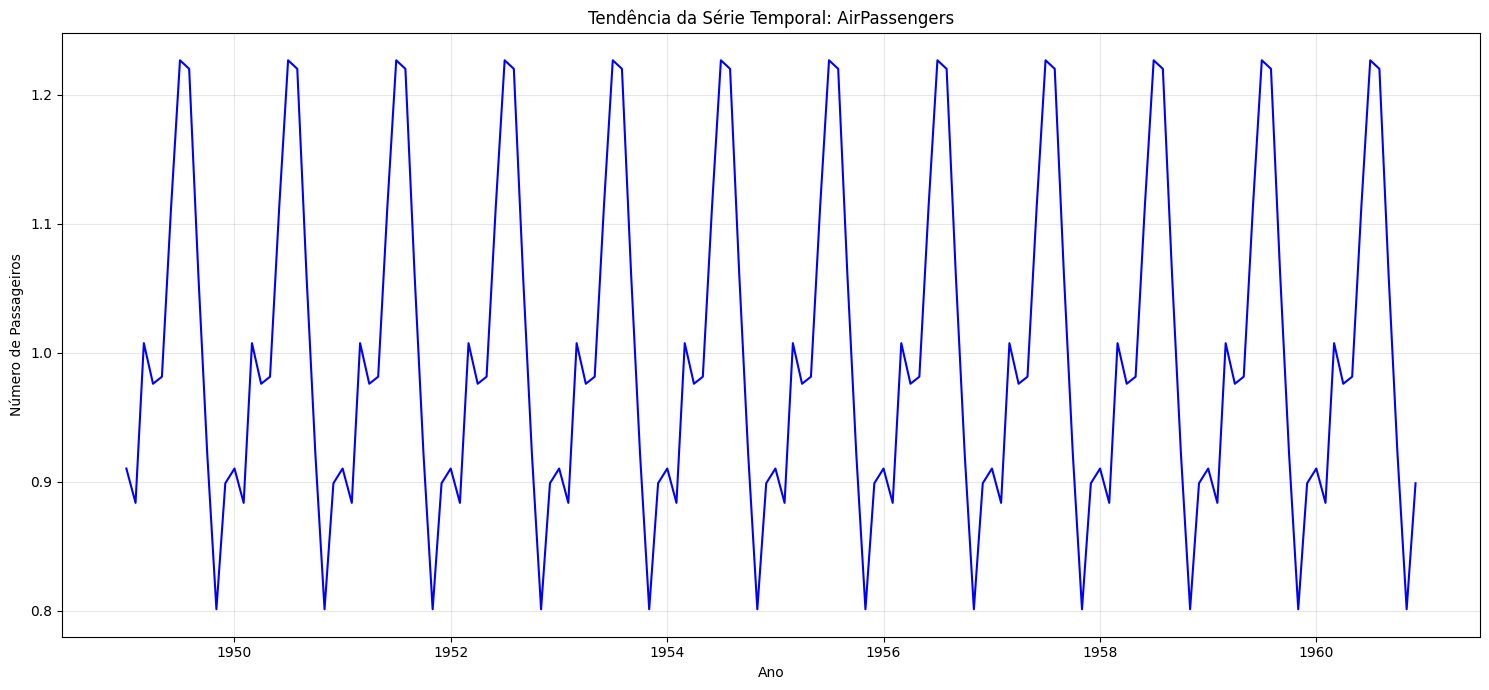

In [10]:
# Gráfico da Sazonalidade
plt.plot(air_passengers.index, decomposicao.seasonal, color='blue', label='Sazonalidade (S)')
plt.xlabel("Ano")
plt.ylabel("Número de Passageiros")
plt.title("Tendência da Série Temporal: AirPassengers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

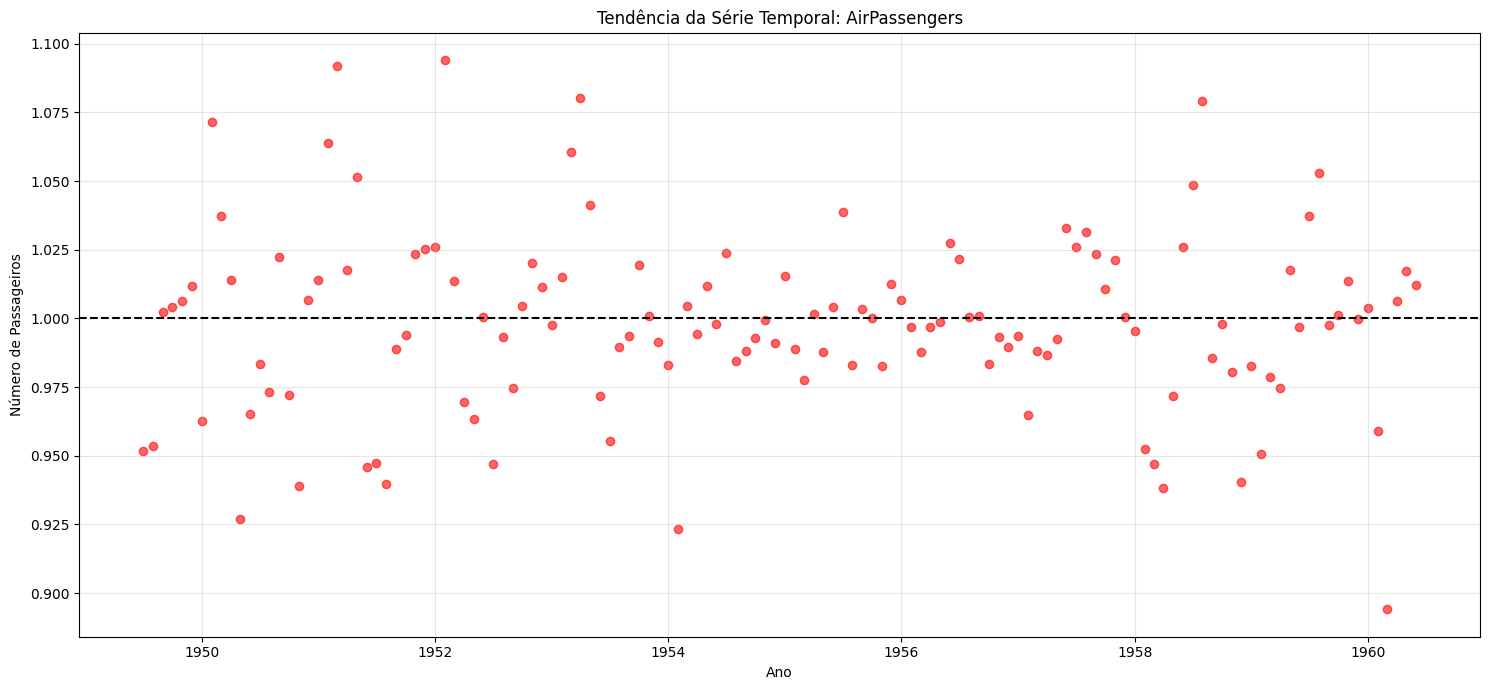

In [11]:
# Gráfico do Ruído / Resíduo
plt.scatter(air_passengers.index, decomposicao.resid, color='red', alpha=0.6, label='Ruído (R)')
plt.axhline(1.0, color='black', linestyle='--')  # Em modelos multiplicativos, a linha de base do ruído é 1.0
plt.xlabel("Ano")
plt.ylabel("Número de Passageiros")
plt.title("Tendência da Série Temporal: AirPassengers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# **Transformações e diferenciaçã**o

A escolha entre Transformação Logarítmica, Transformação Box-Cox e Diferenciação depende do tipo de não-estacionariedade que a série temporal apresenta: variação na variância (dispersão) ou variação na média (tendência/sazonalidade).

## **1. Transformação Logarítmica**
Conceito e Matemática:Aplica a função logarítmica natural ($Y_t' = \ln(Y_t)$) a cada ponto da série. Ela comprime valores altos e expande valores baixos, suavizando o efeito de amplificação.  **Quando utilizar:**
  * Quando a série apresenta heterocedasticidade (variância não constante) e a amplitude das oscilações cresce proporcionalmente ao nível da tendência (sazonalidade multiplicativa).

  * Exige que todos os valores da série sejam estritamente positivos ($Y_t > 0$).

**AirPassengers:** O volume de passageiros cresce ao longo dos anos e a oscilação entre os picos de verão e os vales de inverno aumenta na mesma proporção.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
rcParams['figure.figsize'] =15,7


In [13]:
# Carregar AirPassengers
df = sm.datasets.get_rdataset("AirPassengers").data
air_series = pd.Series(df['value'].values, index=pd.date_range('1949-01-01', periods=len(df), freq='ME'))

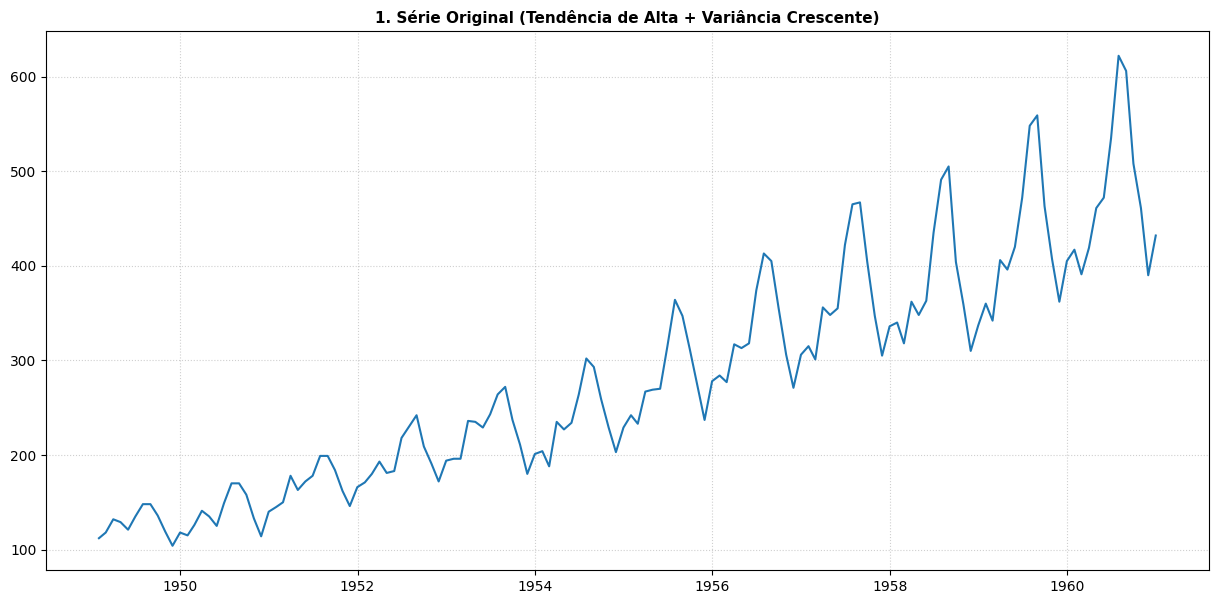

In [14]:
#1. Série original
plt.plot(air_series , color='#1f77b4', lw=1.5)
plt.title('1. Série Original (Tendência de Alta + Variância Crescente)' , fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

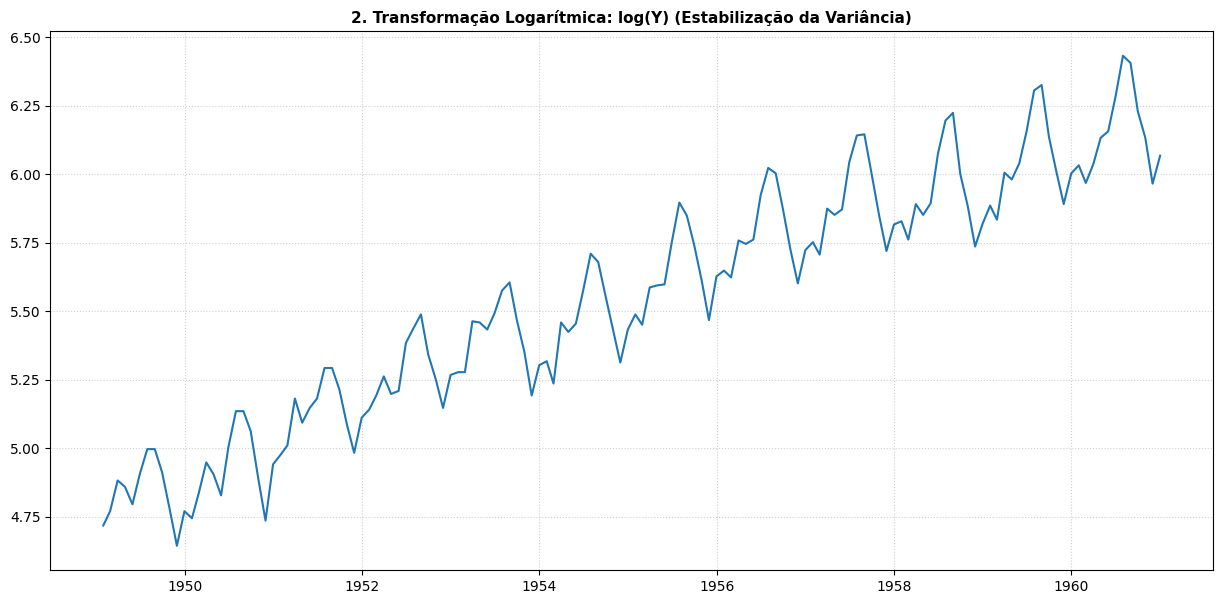

In [15]:

# Aplicação do Logaritmo
air_log = np.log(air_series)

# 2. Transformação Logarítmica
plt.plot(air_log , color='#1f77b4', lw=1.5)
plt.title('2. Transformação Logarítmica: log(Y) (Estabilização da Variância)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## **2. Transformação Box-Cox**

**Conceito e Matemática:** É uma transformação paramétrica dada pela fórmula:$$Y_t^{(\lambda)} = \begin{cases} \frac{Y_t^\lambda - 1}{\lambda} & \text{se } \lambda \neq 0 \\ \ln(Y_t) & \text{se } \lambda = 0 \end{cases}$$O algoritmo encontra estatisticamente o parâmetro ótimo ($\lambda$) que aproxima os dados de uma distribuição normal e estabiliza a variância.

**Quando utilizar:**
* **Quando** a variância cresce ou encolhe de forma não linear que o logaritmo simples ($\lambda = 0$) não consegue corrigir perfeitamente.
* **Quando** se busca automatizar a escolha da melhor transformação funcional para os dados.Exige dados estritamente positivos ($Y_t > 0$).

In [16]:
import pandas as pd
import statsmodels.api as sm
from scipy import stats


In [17]:
# Carregar Sunspots
sunspots_df = sm.datasets.sunspots.load_pandas().data
sunspots_series = pd.Series(sunspots_df['SUNACTIVITY'].values, index=pd.date_range('1700', periods=len(sunspots_df), freq='YE'))


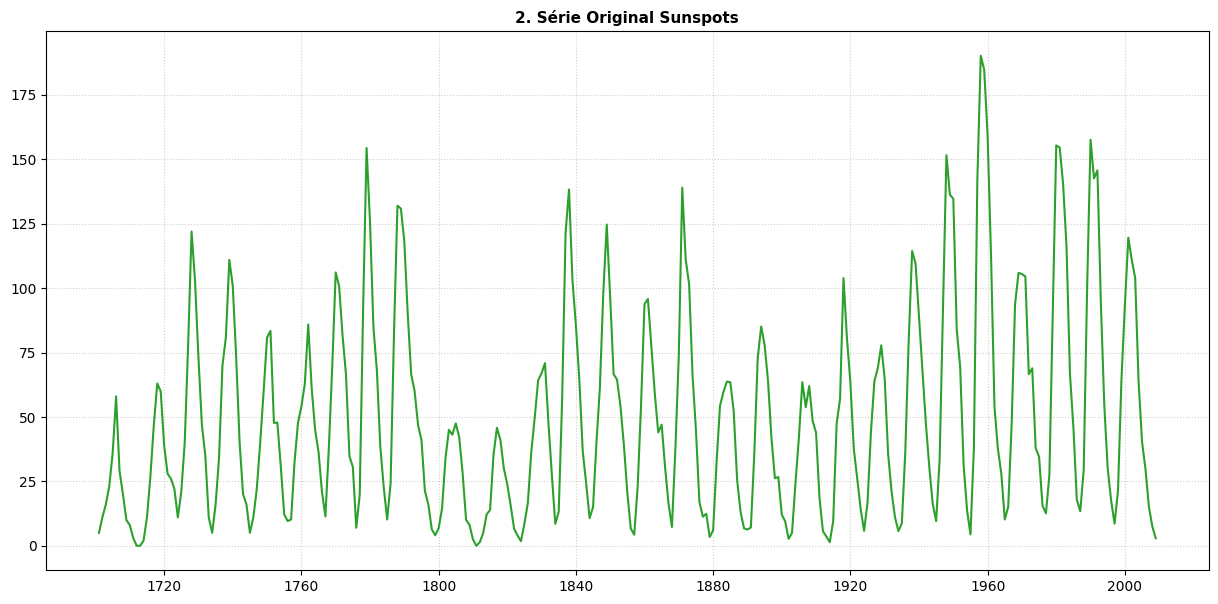

In [18]:
plt.plot(sunspots_series, color='#2ca02c', lw=1.5)
plt.title( '2. Série Original Sunspots', fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [19]:
# Adicionar constante para evitar zero
sunspots_positive = sunspots_series + 1e-5
# Aplicação da Box-Cox com cálculo automático do lambda ótimo
sunspots_boxcox, lmbda = stats.boxcox(sunspots_positive)
print(f"Lambda ótimo calculado: {lmbda:.4f}")




Lambda ótimo calculado: 0.3577


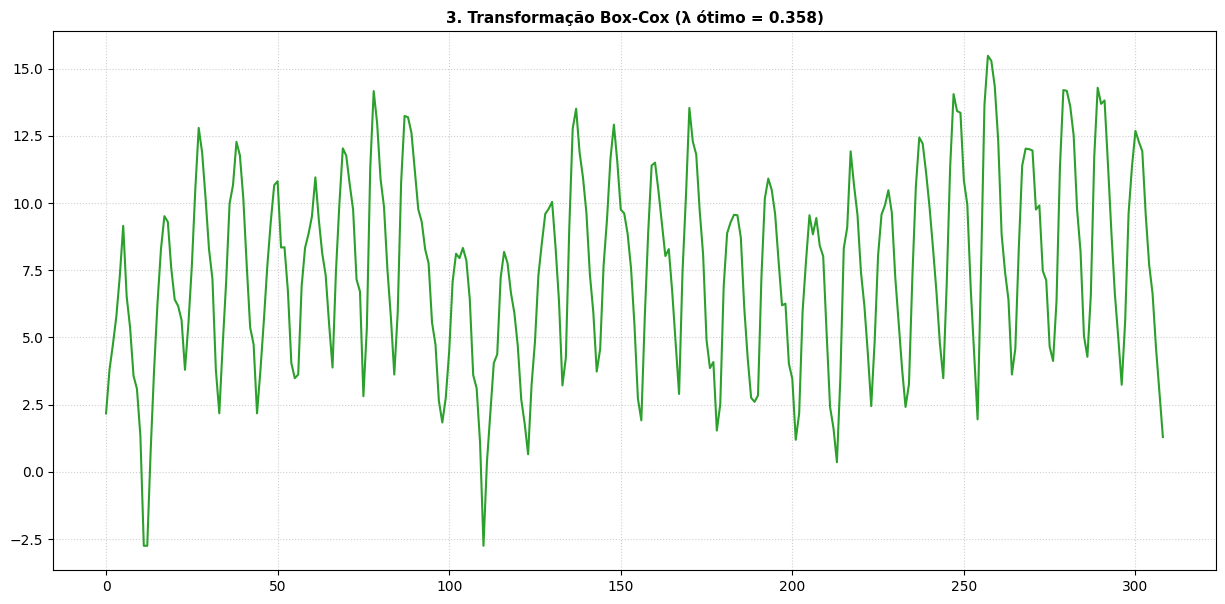

In [20]:
plt.plot(sunspots_boxcox, color='#2ca02c', lw=1.5)
plt.title(f'3. Transformação Box-Cox (λ ótimo = {lmbda:.3f})', fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)

## **3. Diferenciação**

Conceito e Matemática:

Calcula a mudança relativa entre observações consecutivas.

* **Simples (1ª ordem):** $\Delta Y_t = Y_t - Y_{t-1}$ (Remove tendência linear na média).
* **Sazonal (Ordem $s$):** $\Delta_s Y_t = Y_t - Y_{t-s}$ (Remove padrões repetitivos de período $s$, ex: $s=12$ para dados mensais).Quando utilizar:Quando a série não é estacionária na média (possui tendência de alta/baixa ou ciclos sazonais).
* **Diferença fundamental:** Ao contrário do Log e do Box-Cox (que corrigem a variância), a diferenciação corrige a média. É aplicada habitualmente após a transformação de variância.

In [21]:
import pandas as pd
import statsmodels.api as sm

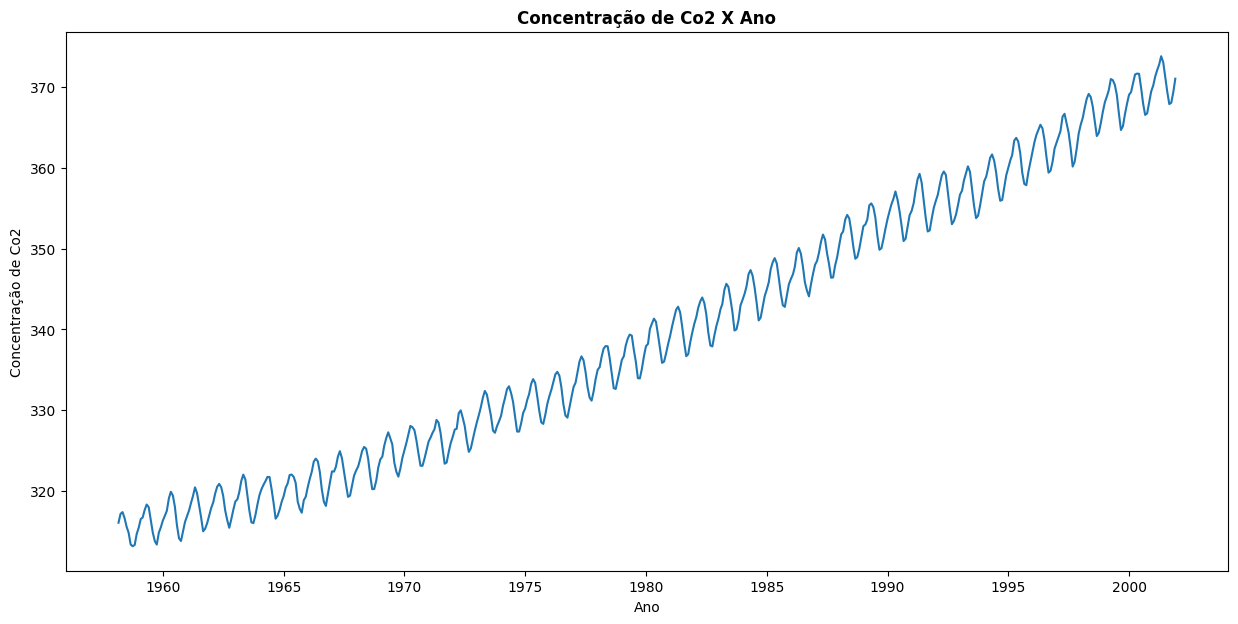

In [22]:
# Carregar CO2
co2_df = sm.datasets.co2.load_pandas().data['co2'].interpolate(method='linear')
co2_mensal = co2_df.resample('MS').mean()
plt.plot(co2_mensal)
plt.title('Concentração de Co2 X Ano', fontweight='bold')
plt.ylabel('Concentração de Co2')
plt.xlabel('Ano')
plt.show()


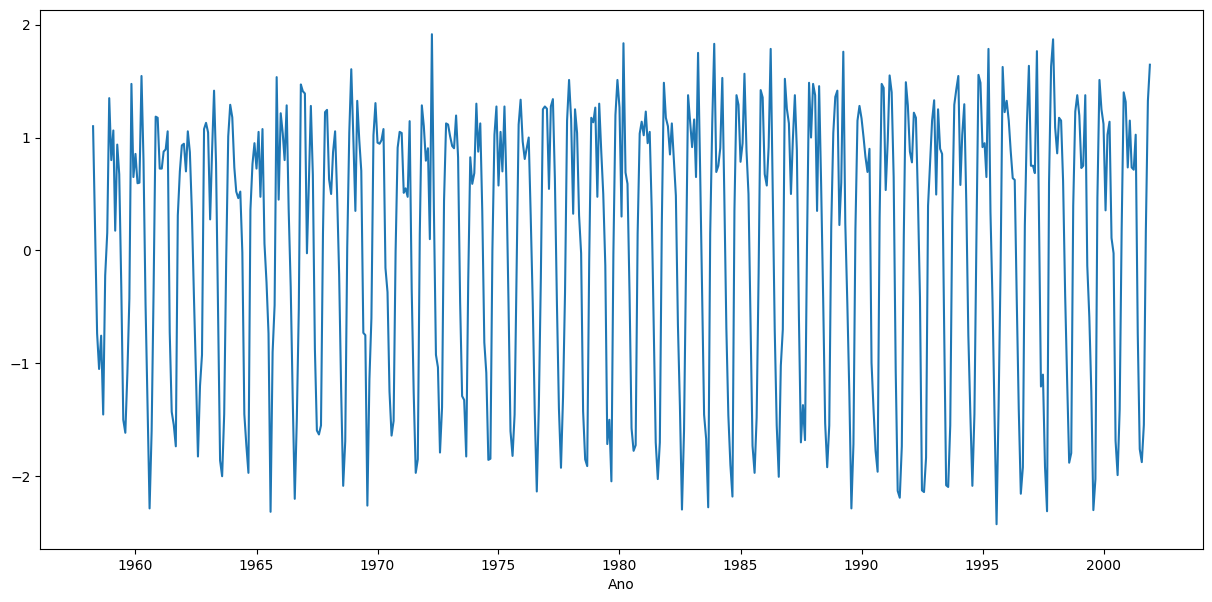

In [23]:
# 1. Diferenciação Simples (lag 1) - Remove a tendência ascendente
co2_diff_1 = co2_mensal.diff(1).dropna()
plt.plot(co2_diff_1)
plt.xlabel('Ano')
plt.show()

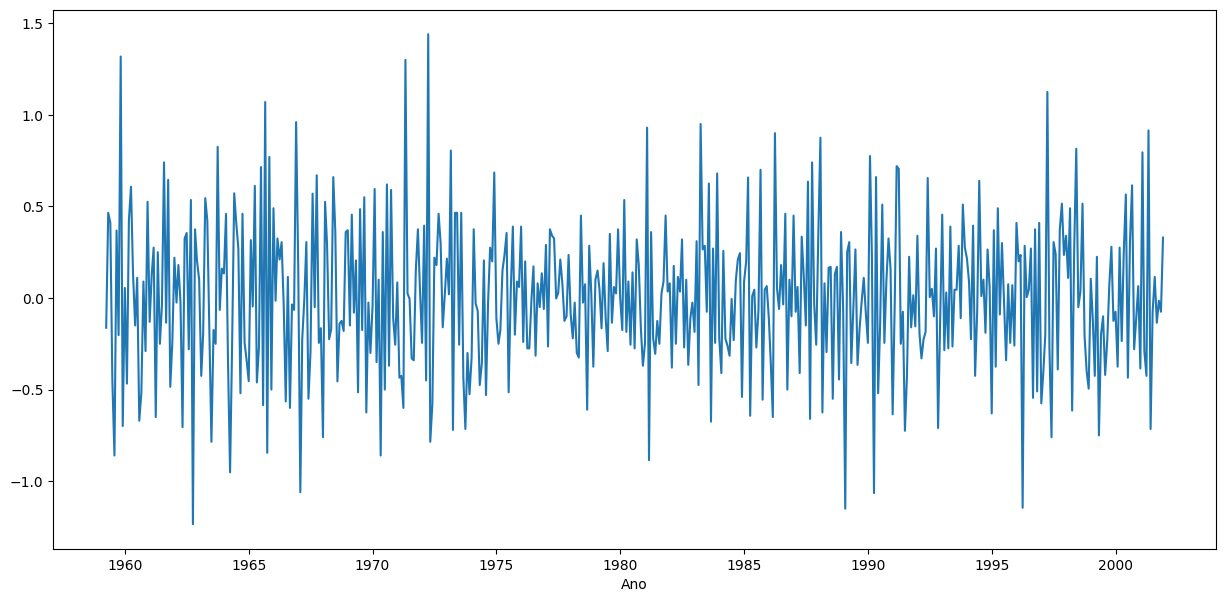

In [24]:

# 2. Diferenciação Sazonal (lag 12) - Remove o ciclo anual sobre a série diferenciada
co2_estacionaria = co2_diff_1.diff(12).dropna()
plt.plot(co2_estacionaria )
plt.xlabel('Ano')
plt.show()


# **Suavização por Média Móvel (Moving Average)**
* **Conceito:** É uma técnica de filtragem usada para atenuar o ruído aleatório de alta frequência e evidenciar a tendência subjacente dos dados. Consiste em substituir cada ponto da série pela média dos $janela$ pontos anteriores (ou ao redor).
* **Simple Moving Average (SMA):** Atribui pesos iguais a todos os observações dentro da janela temporal.Efeito da Janela ($k$): Janelas maiores suavizam mais a série, mas introduzem um atraso (lag) na resposta a mudanças reais de direção.

## **Destaques da Análise Visual**
* **Média Móvel de 3 Meses:** Acompanha de perto as oscilações originais, apenas atenuando o ruído mês a mês.

* **Média Móvel de 12 Meses:** Elimina completamente os picos de verão e vales de inverno (sazonalidade anual), revelando de forma limpa a tendência real de crescimento da aviação comercial no períod

In [25]:
# 2. Calcular as Médias Móveis Simples (SMA)
sma_3 = air_passengers.rolling(window=3).mean()   # Suavização curta (trimestral)
sma_6 = air_passengers.rolling(window=6).mean()   # Suavização média (semestral)
sma_12 = air_passengers.rolling(window=12).mean() # Suavização longa (remove sazonalidade anual)

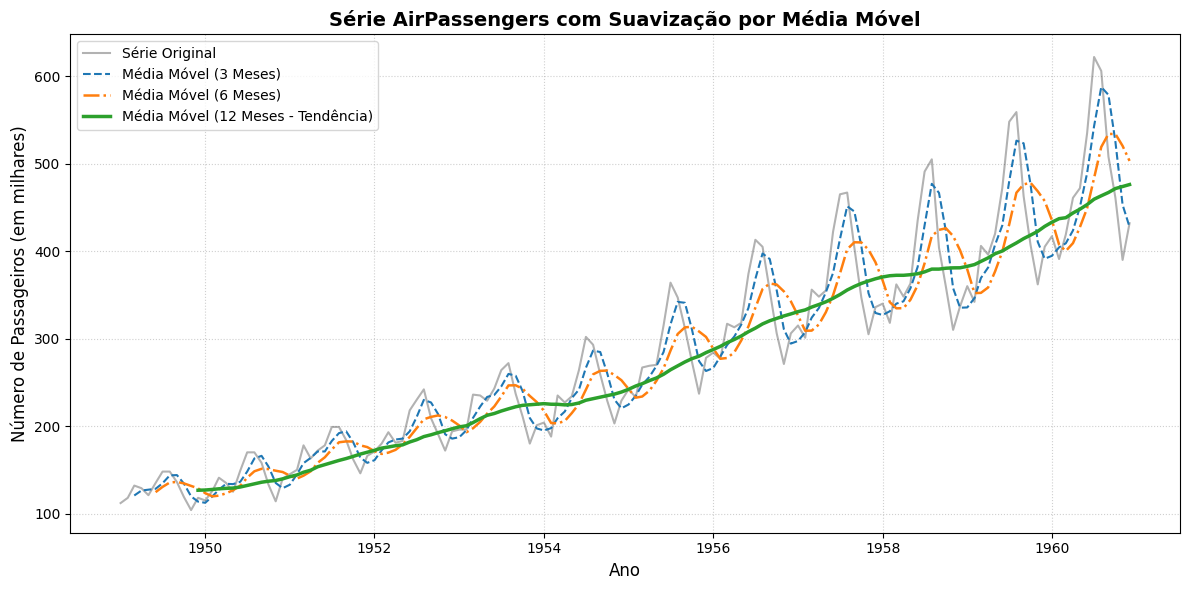

In [26]:
# 3. Construção do Gráfico
plt.figure(figsize=(12, 6))

# Plot da série original
plt.plot(air_passengers, label='Série Original', color='black', alpha=0.3, linewidth=1.5)

# Plot das médias móveis
plt.plot(sma_3, label='Média Móvel (3 Meses)', color='#1f77b4', linestyle='--', linewidth=1.5)
plt.plot(sma_6, label='Média Móvel (6 Meses)', color='#ff7f0e', linestyle='-.', linewidth=1.8)
plt.plot(sma_12, label='Média Móvel (12 Meses - Tendência)', color='#2ca02c', linewidth=2.5)

# Configurações de estilo
plt.title('Série AirPassengers com Suavização por Média Móvel', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Passageiros (em milhares)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Exibir o gráfico

plt.show()